# 01 — Observe MSD

Purpose: eyeball MSD samples to derive procedural rules.

For each sample we look at three modalities side-by-side:
1. **`struct_in`** — fixed boundary + structural elements (input)
2. **`graph_in`** — bubble diagram: node = zoning_type, edge = connectivity (input)
3. **`graph_out`** — same graph + room polygons + room_type (target)

Iterate through several `SAMPLE_ID`s and write observations at the bottom.

In [1]:
import pickle
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from shapely.geometry import Polygon

REPO = Path.cwd().resolve().parents[1]
DATA = REPO / "datasets" / "msd" / "raw" / "modified-swiss-dwellings-v2" / "train"
sys.path.insert(0, str(REPO))

from datasets.msd.constants import ROOM_NAMES, ZONING_NAMES  # noqa: E402

print("REPO:", REPO)
print("DATA:", DATA, "exists?", DATA.exists())
print("ROOM_NAMES:", ROOM_NAMES)
print("ZONING_NAMES:", ZONING_NAMES)

REPO: D:\Github\GSDiff
DATA: D:\Github\GSDiff\datasets\msd\raw\modified-swiss-dwellings-v2\train exists? True
ROOM_NAMES: ['Bedroom', 'Livingroom', 'Kitchen', 'Dining', 'Corridor', 'Stairs', 'Storeroom', 'Bathroom', 'Balcony', 'Structure', 'Door', 'Entrance Door', 'Window']
ZONING_NAMES: ['Zone1', 'Zone2', 'Zone3', 'Zone4', 'Structure', 'Door', 'Entrance Door', 'Window']


In [2]:
SAMPLE_ID = "10000"  # try also: 10009, 10014, 10019, 10029

def load_sample(sid):
    with open(DATA / "graph_in" / f"{sid}.pickle", "rb") as f:
        g_in = pickle.load(f)
    with open(DATA / "graph_out" / f"{sid}.pickle", "rb") as f:
        g_out = pickle.load(f)
    struct = np.load(DATA / "struct_in" / f"{sid}.npy")
    full = np.load(DATA / "full_out" / f"{sid}.npy")
    return g_in, g_out, struct, full

g_in, g_out, struct, full = load_sample(SAMPLE_ID)

print(f"graph_in : {g_in.number_of_nodes()} nodes, {g_in.number_of_edges()} edges")
print(f"graph_out: {g_out.number_of_nodes()} nodes, {g_out.number_of_edges()} edges")
print(f"struct_in: {struct.shape}, {struct.dtype}, range=[{struct.min():.2f}, {struct.max():.2f}]")
print(f"full_out : {full.shape}, {full.dtype}, range=[{full.min():.2f}, {full.max():.2f}]")
print()
print("zoning_type counts:", {ZONING_NAMES[t]: c for t, c in sorted(Counter(d['zoning_type'] for _, d in g_in.nodes(data=True)).items())})
print("room_type counts  :", {ROOM_NAMES[t]: c for t, c in sorted(Counter(d['room_type'] for _, d in g_out.nodes(data=True)).items())})
print("edge connectivity :", Counter(d['connectivity'] for _, _, d in g_in.edges(data=True)))

graph_in : 41 nodes, 39 edges
graph_out: 41 nodes, 39 edges
struct_in: (512, 512, 3), float16, range=[-19.48, 255.00]
full_out : (512, 512, 3), float16, range=[-16.11, 16.73]

zoning_type counts: {'Zone1': 13, 'Zone2': 12, 'Zone3': 10, 'Zone4': 6}
room_type counts  : {'Bedroom': 13, 'Kitchen': 5, 'Corridor': 7, 'Stairs': 2, 'Storeroom': 2, 'Bathroom': 6, 'Balcony': 6}
edge connectivity : Counter({'door': 32, 'entrance': 7})


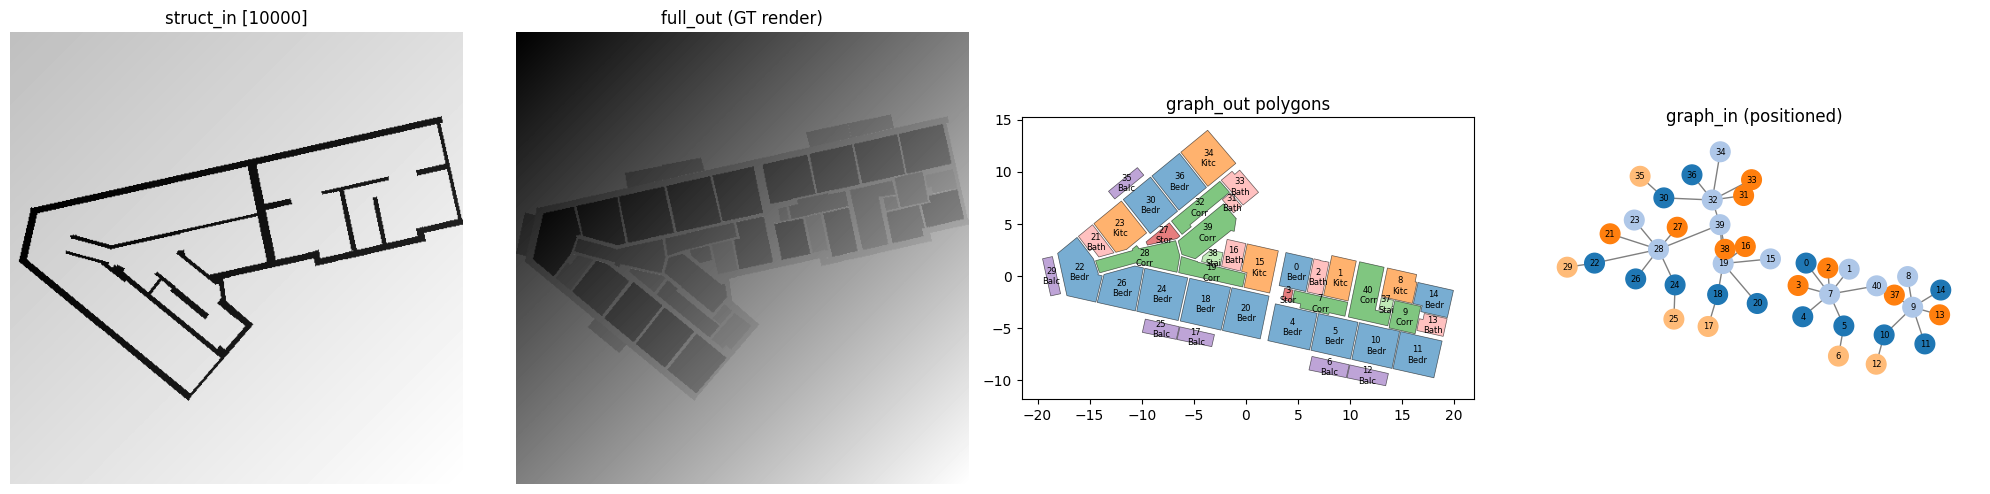

In [3]:
def visualize(g_in, g_out, struct, full, sample_id):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    cmap = plt.cm.tab20

    # 1. struct_in (boundary + structure) — collapse channels to gray
    axes[0].imshow(struct.astype(np.float32).mean(axis=2), cmap='gray')
    axes[0].set_title(f'struct_in [{sample_id}]')
    axes[0].axis('off')

    # 2. full_out (ground-truth rendered plan)
    axes[1].imshow(full.astype(np.float32).mean(axis=2), cmap='gray')
    axes[1].set_title('full_out (GT render)')
    axes[1].axis('off')

    # 3. graph_out polygons (the answer in geometric form)
    ax = axes[2]
    for n, d in g_out.nodes(data=True):
        poly = Polygon(d['geometry'])
        x, y = poly.exterior.xy
        ax.fill(x, y, color=cmap(d['room_type'] % 20), alpha=0.6, edgecolor='black', linewidth=0.5)
        cx, cy = poly.centroid.coords[0]
        ax.text(cx, cy, f"{n}\n{ROOM_NAMES[d['room_type']][:4]}", ha='center', va='center', fontsize=6)
    ax.set_aspect('equal')
    ax.set_title('graph_out polygons')

    # 4. graph_in as bubble diagram, positioned by g_out centroids
    ax = axes[3]
    pos = {}
    for n in g_in.nodes:
        if n in g_out.nodes and 'centroid' in g_out.nodes[n]:
            c = g_out.nodes[n]['centroid']
            pos[n] = (float(c[0]), float(c[1]))
        else:
            pos[n] = (0.0, 0.0)
    node_colors = [cmap(d['zoning_type'] % 20) for _, d in g_in.nodes(data=True)]
    nx.draw(g_in, pos=pos, ax=ax, node_color=node_colors, with_labels=True, node_size=200, font_size=6, edge_color='gray')
    ax.set_aspect('equal')
    ax.set_title('graph_in (positioned)')

    plt.tight_layout()
    return fig

_ = visualize(g_in, g_out, struct, full, SAMPLE_ID)
plt.show()

## Per-room geometric stats

For this one sample: area, aspect ratio, vertex count, convexity per room. Eyeball whether your gut feeling about "bedrooms are ~12㎡" actually matches.

In [4]:
import pandas as pd

rows = []
for n, d in g_out.nodes(data=True):
    poly = Polygon(d['geometry'])
    bbox = poly.minimum_rotated_rectangle
    bx, by = bbox.exterior.coords.xy
    edges = [((bx[i+1]-bx[i])**2 + (by[i+1]-by[i])**2) ** 0.5 for i in range(4)]
    long, short = max(edges[:2]), min(edges[:2])
    rows.append({
        'node': n,
        'room_type': ROOM_NAMES[d['room_type']],
        'area_m2': round(poly.area, 2),
        'aspect': round(long / max(short, 1e-6), 2),
        'vertices': len(d['geometry']) - 1,
        'convexity': round(poly.area / poly.convex_hull.area, 2),
        'degree': g_out.degree(n),
    })

df = pd.DataFrame(rows).sort_values('room_type')
df

,node,room_type,area_m2,aspect,vertices,convexity,degree
29,29,Balcony,3.56,3.75,4,1.00,1
12,12,Balcony,4.69,2.99,4,1.00,1
25,25,Balcony,4.27,2.55,4,1.00,1
6,6,Balcony,4.77,2.74,4,1.00,1
17,17,Balcony,4.15,2.73,4,1.00,1
35,35,Balcony,3.43,3.78,4,1.00,1
31,31,Bathroom,1.68,1.65,6,1.00,1
16,16,Bathroom,4.93,1.48,4,1.00,1
2,2,Bathroom,4.81,2.20,8,1.00,1
13,13,Bathroom,4.33,1.49,8,0.98,1


## Browse several samples quickly

Run the cell below to flip through 6 random samples. Watch for patterns:

- Where does the entrance door sit relative to corridors?
- Do bedrooms always touch the exterior boundary?
- How does the hub node (Living / Corridor) connect to everything?
- Are L-shaped rooms common, or mostly rectangles?
- Typical shared-wall length between (Living, Kitchen) vs (Living, Bedroom)?

total train samples: 4572


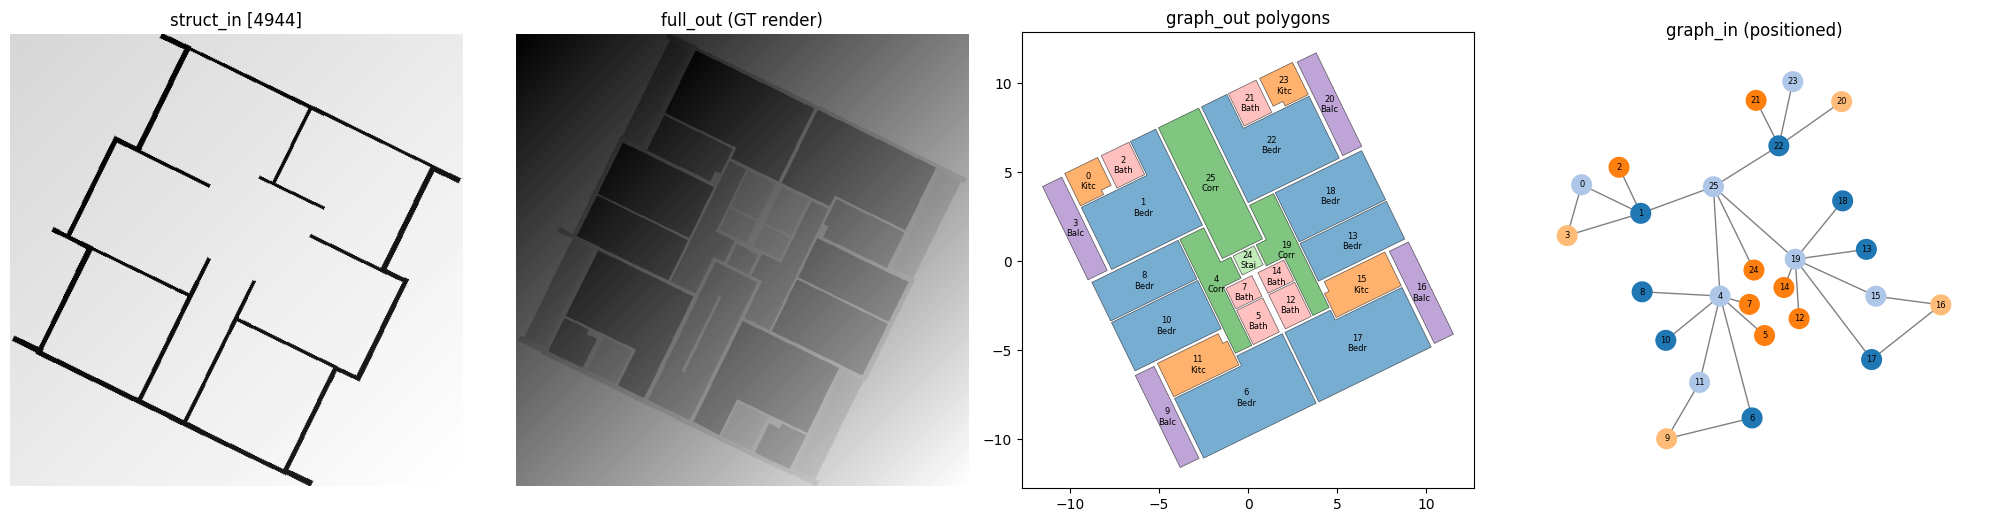

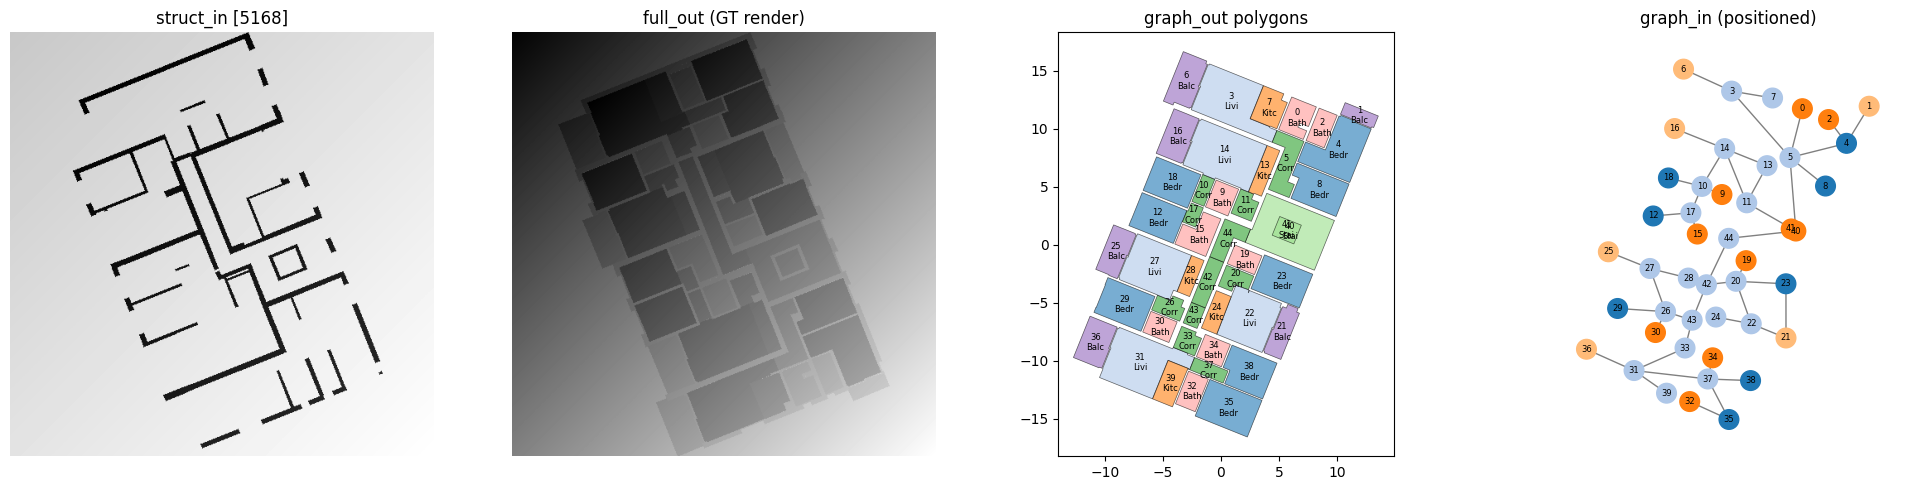

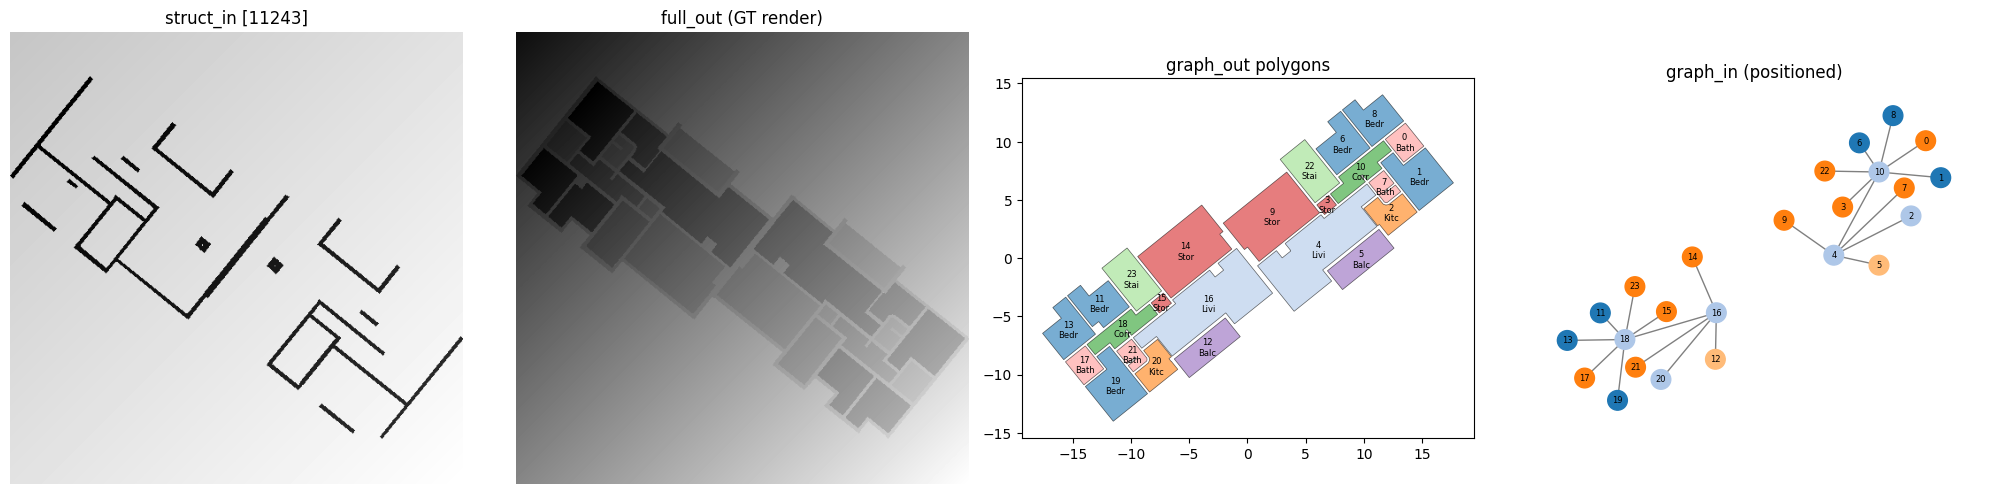

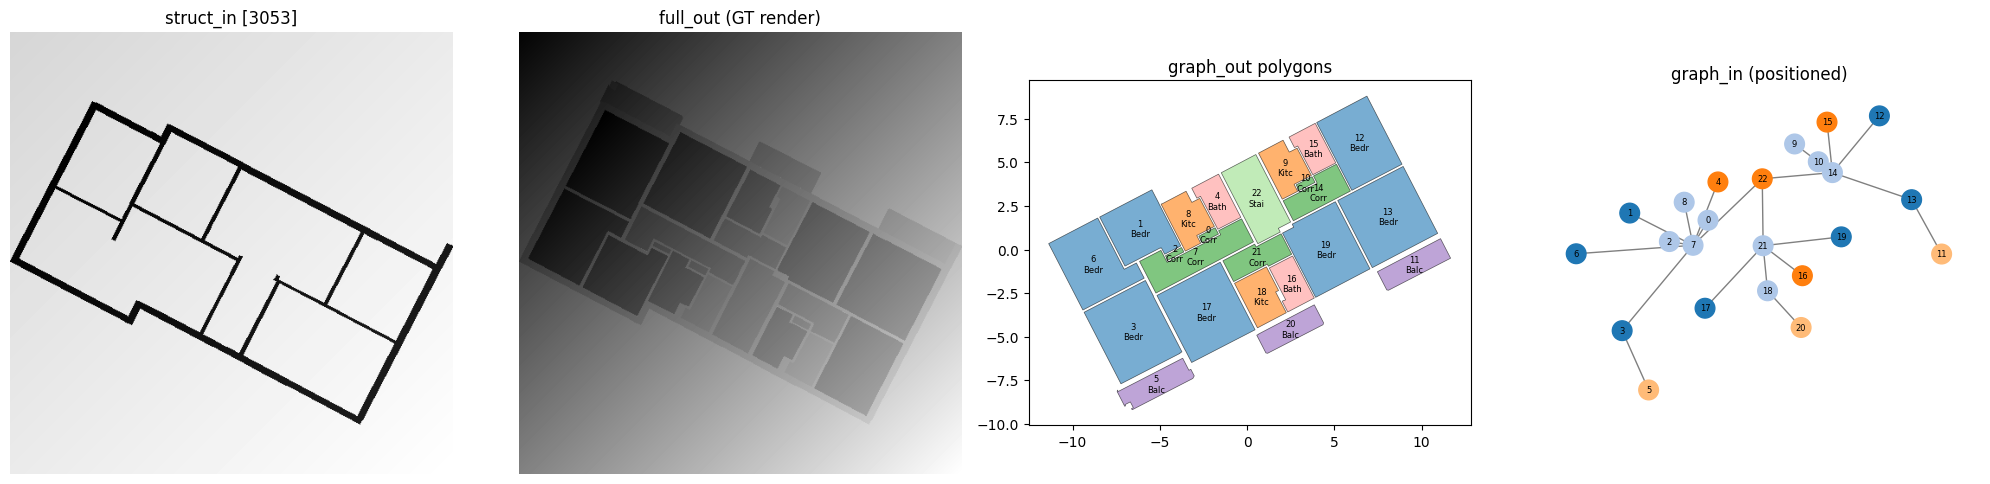

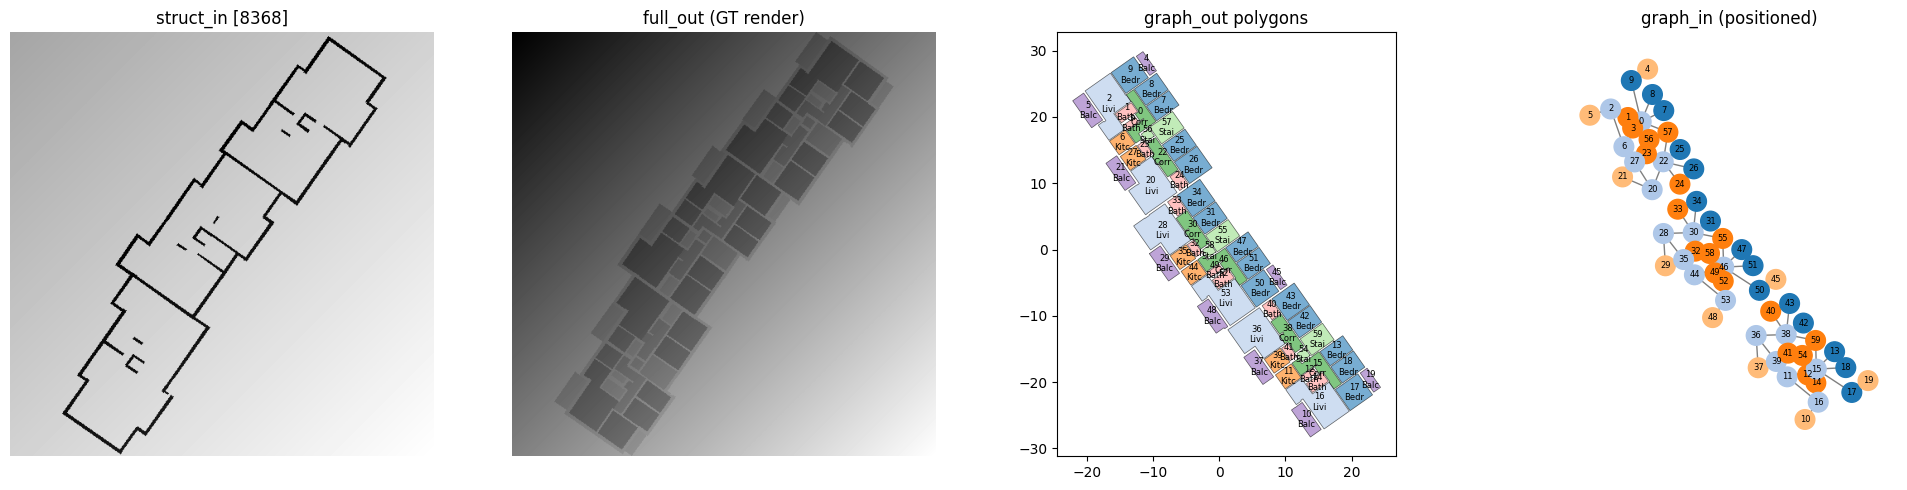

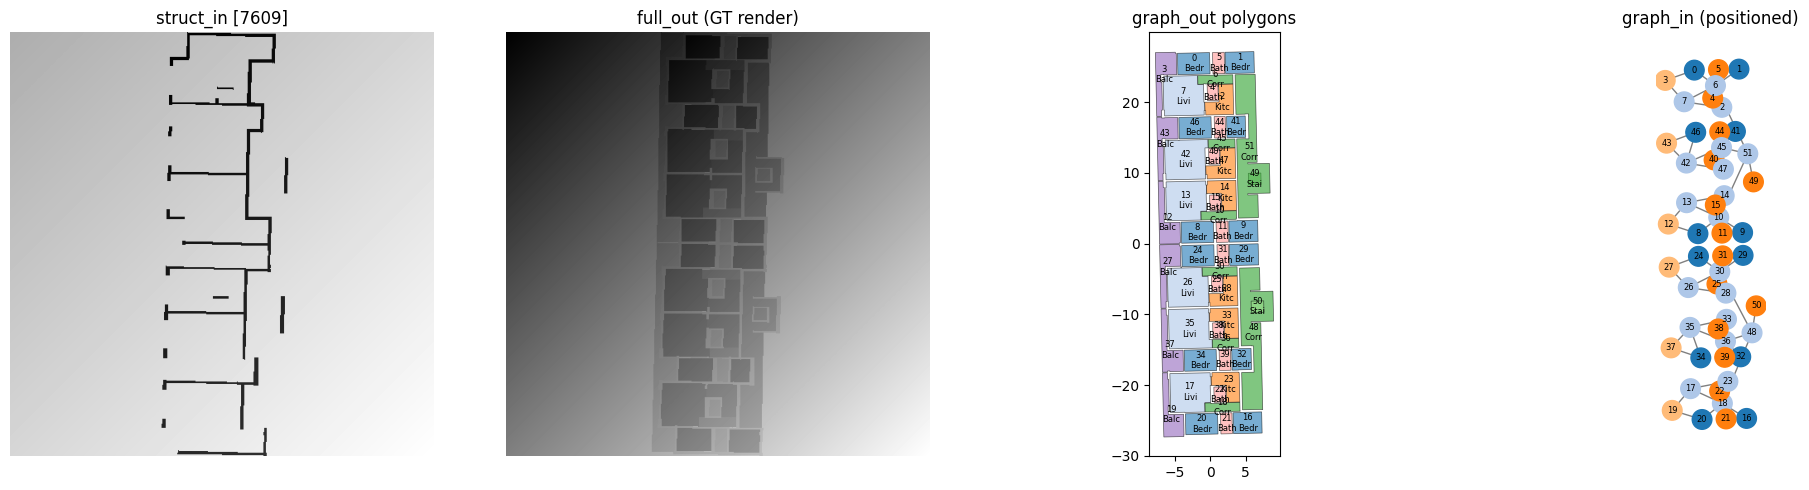

In [5]:
import random

all_ids = sorted([p.stem for p in (DATA / 'graph_in').glob('*.pickle')])
print(f"total train samples: {len(all_ids)}")

random.seed(0)
for sid in random.sample(all_ids, 6):
    g_in, g_out, struct, full = load_sample(sid)
    visualize(g_in, g_out, struct, full, sid)
    plt.show()

## Observations → rules

_Fill in as you browse. Each bullet becomes a rule or a constant in `procedural/rules.py`._

- Bedroom typical area: ?
- Bathroom typical area: ?
- Hub node identification: ?
- Adjacency types most common: ?
- Door placement: ?
- ...